# Epistemic Driven Epistemic Landscapes (EDEL) Pipeline

This notebook demonstrates the full modular EDEL pipeline with **persistent artifact caching**.

## 0. Parameters and setup

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

# EDEL Pipeline Imports
from edel.config.defaults import RUN_CONFIG
from edel.io.llm import get_llm_client
from edel.io.artifact import make_stage_artifact, save_artifact, load_artifact
from edel.pipeline import (
    run_data_stage, run_structuring_stage, run_embedding_stage,
    run_projection_stage, run_vector_field_stage, run_clustering_stage,
    run_labeling_stage, run_landscape_stage
)
from edel.viz import (
    plot_abstract_length_dist, plot_publication_year_dist, plot_citation_dist,
    plot_projection_2d, plot_transition_signatures, plot_movement_magnitudes,
    plot_vector_field, plot_field_magnitude, plot_field_density,
    plot_clusters_on_landscape, plot_field_clusters, plot_cluster_trajectories,
    print_cluster_summaries, plot_epistemic_map,
    plot_landscape_3d, plot_landscape_contour
)

# Global Configuration
BASE_PATH = Path(os.getcwd()).parent / "artifacts"
BASE_PATH.mkdir(parents=True, exist_ok=True) # Ensure root artifacts exists
FORCE_RECOMPUTE = False
config = RUN_CONFIG.copy()

print(f"✅ Setup complete. Artifacts will be saved to: {BASE_PATH}")

/home/correia/miniforge3/envs/edel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup complete. Artifacts will be saved to: /home/correia/edel/artifacts


In [2]:
config = {

    "processing_mode": "simple", # "simple" | "batch"
    "embedding_mode": "aspects", # "aspects" | "documents"

    "data": {
        "provider": {
            "type": "openalex",
            "topic_id": "T10102",
            "topic_name": "Scientometrics",
            "region": None,
            "params": {
                "n_documents": 10,
                "avg_length": 150,
            }
         },
        "transforms": [
            {"type": "shuffle_words"}
        ]
    },

    "structured_abstracts": {
        "provider": "openai",
        "model": "gpt-5-mini",
        "min_sentences": 4,
        "min_tokens": 80,
    },

    "embedding": {
        "mode": "multi", # multi | single | abstract
        "provider": "openai",
        "model": "text-embedding-ada-002",
        "n_dimensions": 1536,
        "batch_size": 5000
    },

    "dimensionality_reduction": {
        "method": "diffusion",
        "n_neighbors": 15,
        "random_state": 0,
        "min_dist": 0.1,
        "metric": "cosine",
    },

    "vector_field": {
        "method": "diffusion",
        "grid_size": 25,
        "min_count": 3,
        "smooth_sigma": 1.0,
        "compute_divergence": True,
        "compute_magnitude": True,
    },

    "clustering": {
        "domain": {
            "source": "proj_p",
            "algorithm": "hdbscan",
            "params": {
                "min_cluster_size": 15,
            },
        },
        "field": {
            "source": "field",
            "algorithm": "hdbscan",
            "params": {
                "min_cluster_size": 10,
            },
        },
        "style": {
            "source": "features",
            "algorithm": "gmm",
            "params": {
                "n_components": 4,
            },
        },
        "operator": {
            "source": "operators",
            "algorithm": "hdbscan",
            "params": {
                "min_cluster_size": 20,
            },
        },
    },

    "labeling": {
        "provider": "openai",
        "model": "gpt-5-mini",
        "text_column": "abstract_text",
        "topic": None,
        "language": "en",
        "axis": {
            "enabled": True,
            "projection": "diffusion",
            "n_samples": 5,
        },
        "clusters": {
            "enabled": True,
            "cluster_keys": [
                "domain",
                "style",
                "operator",
                "field"
            ],
            "n_samples": 5,
        }
    },

    "landscape": {
      "metric": "cited_by_count",
      "log_scale": True,
      "grid": {
        "num_bins": 50,
        "sigma": 1.5
      },
      "scale": 12.0,
      "color_cluster": "cluster_domain",
      "style_cluster": "cluster_style",
      "field": {
        "enabled": True,
        "type": "total",
        "step": 2,
        "scale": 0.07,
        "width": 1
      }
    }
}

## 1. Data Collection

Stage 1: Loaded existing dataset artifact.


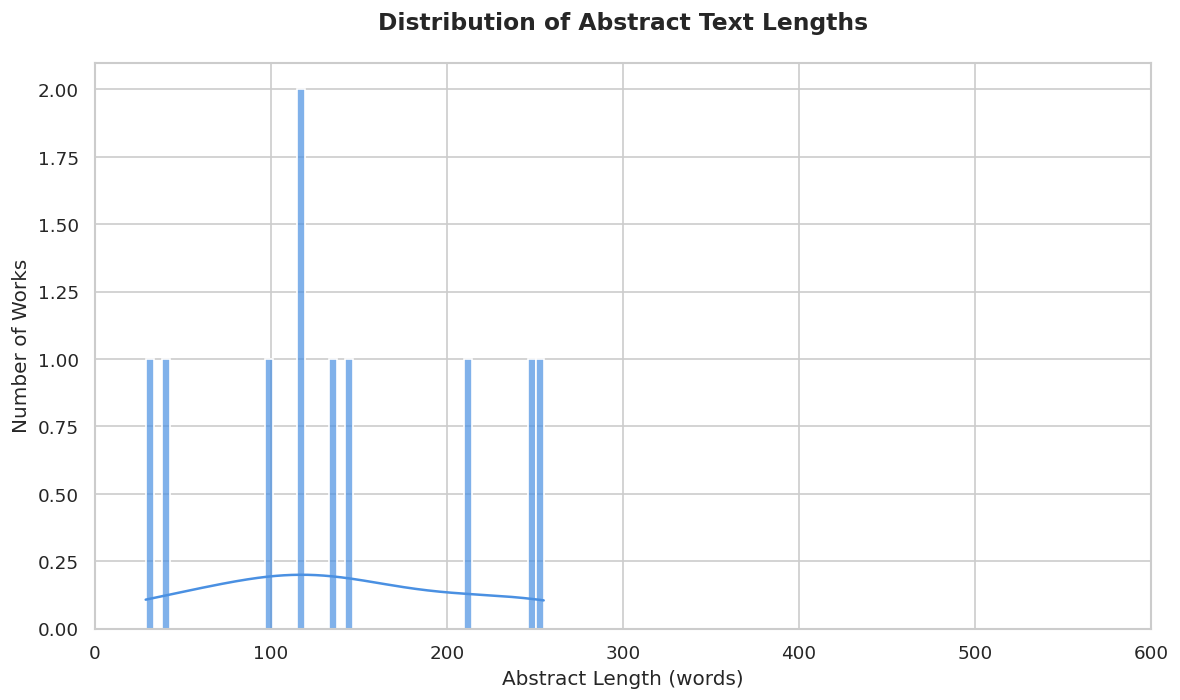

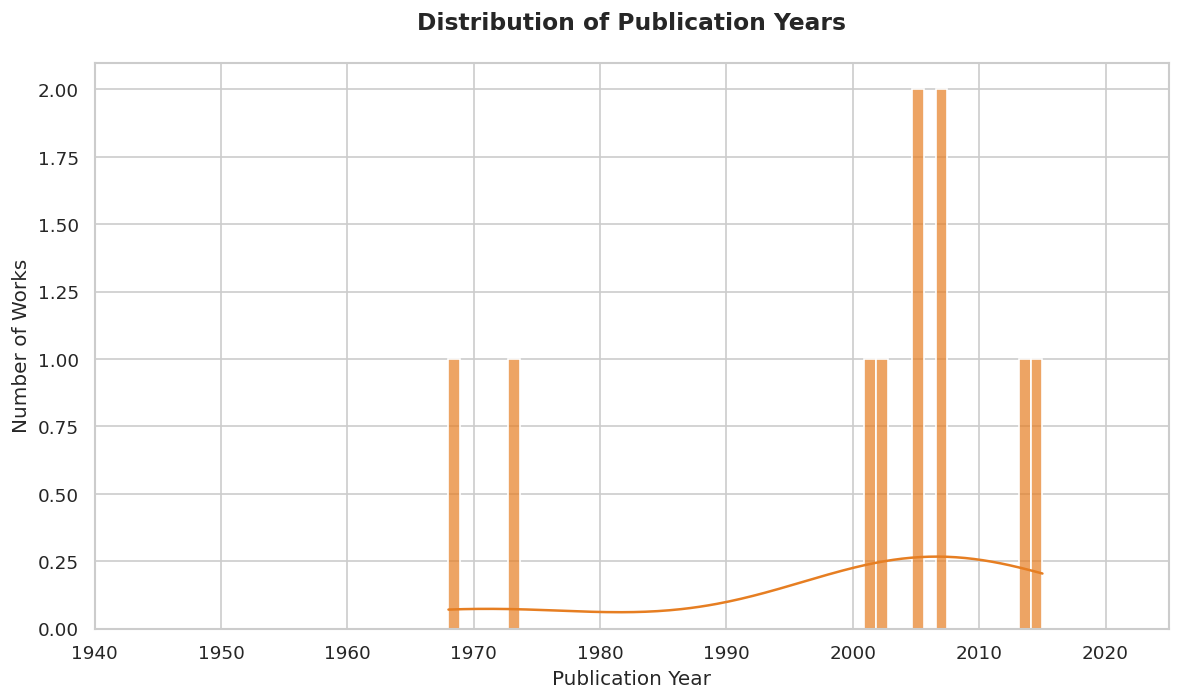

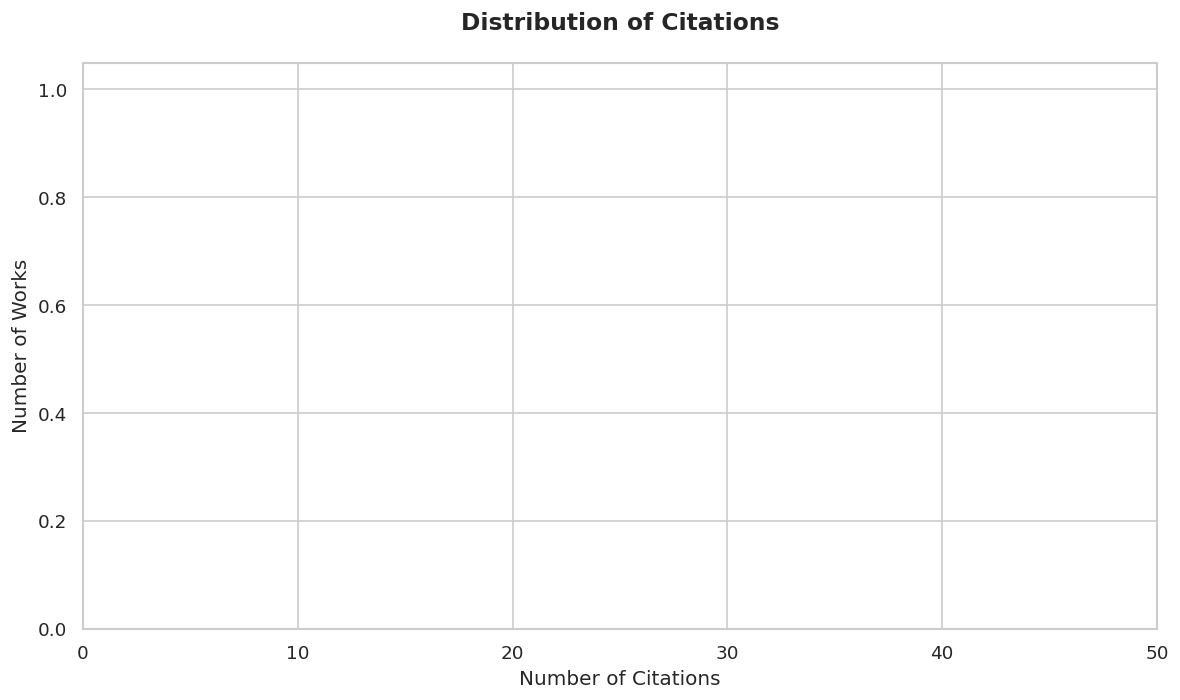

In [4]:
art_data = make_stage_artifact(config, BASE_PATH, "data_collection", "dataset")
try:
    if FORCE_RECOMPUTE: raise FileNotFoundError()
    df = load_artifact(art_data)
    print("Stage 1: Loaded existing dataset artifact.")
except:
    print("Stage 1: Running data collection...")
    df = run_data_stage(config)
    save_artifact(art_data, df)

plot_abstract_length_dist(df)
plot_publication_year_dist(df)
plot_citation_dist(df)

## 2. Structuring (Epistemic Segmentation)

In [6]:
art_sa = make_stage_artifact(config, BASE_PATH, "structured_abstracts", "sa")
art_report = make_stage_artifact(config, BASE_PATH, "structured_abstracts", "filter_report")
try:
    if FORCE_RECOMPUTE: raise FileNotFoundError()
    df = load_artifact(art_sa)
    filter_report = load_artifact(art_report)
    print("Stage 2: Loaded existing structured artifact and report.")
except:
    print("Stage 2: Running structuring abstracts...")
    df, filter_report = run_structuring_stage(df, config)
    save_artifact(art_sa, df)
    save_artifact(art_report, filter_report)

print("Filter Summary Report:")
for k, v in filter_report.items():
    print(f" - {k}: {v}")

df.head(2)

Stage 2: Running structuring abstracts...
Filtered to 8 abstracts for structuring.
Filter Report: {'initial_count': 10, 'missing_abstract_count': 0, 'insufficient_sentences_count': 2, 'insufficient_tokens_count': 0, 'final_count': 8}


Structuring Abstracts: 100%|██████████| 8/8 [03:14<00:00, 24.35s/it]


Filter Summary Report:
 - initial_count: 10
 - missing_abstract_count: 0
 - insufficient_sentences_count: 2
 - insufficient_tokens_count: 0
 - final_count: 8


,source_provider,id,title,abstract_text,authorships,publication_year,cited_by_count,citation_normalized_percentile,doi,oa_status,...,countries,topics,type,language,keywords,has_fulltext,problem,method,finding,interpretation
1,openalex,https://openalex.org/W1897139626,Estimating the reproducibility of psychologica...,Reproducibility is a defining feature of scien...,"[{'affiliations': [], 'author': {'display_name...",2015,8586,0.999933,https://doi.org/10.1126/science.aac4716,green,...,[],"[Meta-analysis and systematic reviews, sciento...",article,en,"[Replication (statistics), Confidence interval...",True,abstract:\nReproducibility is a defining featu...,abstract:\nWe conducted replications of 100 ex...,abstract:\nReplication effects were half the m...,abstract:\nCorrelational tests suggest that re...
3,openalex,https://openalex.org/W3125707221,Bibliometric Methods in Management and Organiz...,We aim to develop a meaningful single-source r...,[{'affiliations': [{'institution_ids': array([...,2014,6366,0.998341,https://doi.org/10.1177/1094428114562629,closed,...,[SI],"[Innovation and Knowledge Management, scientom...",article,en,"[Bibliographic coupling, Citation analysis, Ci...",False,abstract:\nWe aim to develop a meaningful sing...,abstract:\nWe introduce the bibliometric metho...,abstract:\nTo demonstrate bibliometric methods...,abstract:\nSuch methods introduce a measure of...


## 3. Text Embeddings

In [9]:
art_emb = make_stage_artifact(config, BASE_PATH, "embeddings", "embeddings")
try:
    if FORCE_RECOMPUTE: raise FileNotFoundError()
    df = load_artifact(art_emb)
    print("Stage 3: Loaded existing embedding artifact.")
except:
    print("Stage 3: Running embedding aspects...")
    df = run_embedding_stage(df, config)
    save_artifact(art_emb, df)

print("Embeddings ready.")

Stage 3: Running embedding aspects...
Dividing 32 embedding requests into 1 batch(es) (size: 5000).

--- Processing Embedding Batch 1/1 (32 items) ---
Started batch job: batch_69e64265db9081908faa3fb176b288e8. Waiting for completion...
[16:12:38] Status: validating, Completed: 0/0
[16:12:48] Status: in_progress, Completed: 0/32
[16:12:58] Status: in_progress, Completed: 2/32
[16:13:08] Status: in_progress, Completed: 28/32
[16:13:19] Status: in_progress, Completed: 28/32
[16:13:29] Status: in_progress, Completed: 28/32
[16:13:39] Status: in_progress, Completed: 28/32
[16:13:49] Status: in_progress, Completed: 28/32
[16:14:00] Status: finalizing, Completed: 32/32
Batch 1 completed and results collected.
Embeddings ready.


## 4. Dimensionality Reduction (Projection)

✅ Stage 4: Proactively loaded dependency (Stage 3) from artifact.
Stage 4: Running projection...
Projecting 4 aspects into common diffusion space...
Transforming method aspect...
Transforming finding aspect...
Transforming interpretation aspect...
Calculating transition signatures and magnitudes...


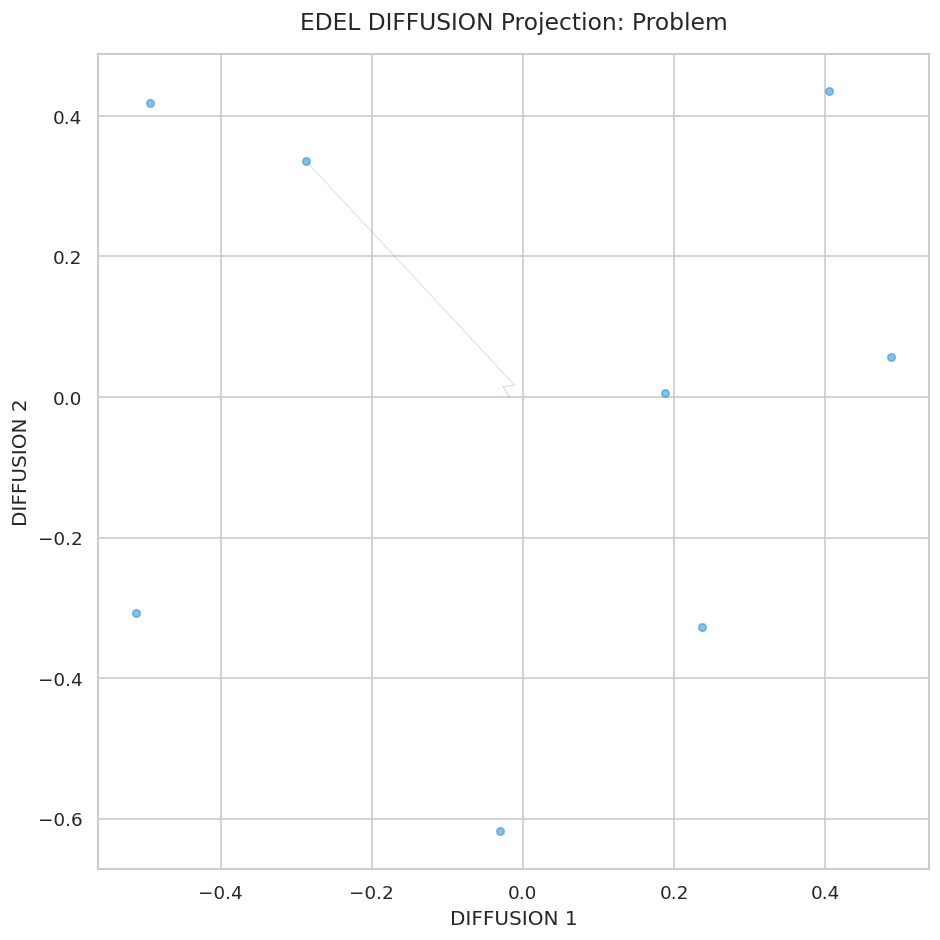

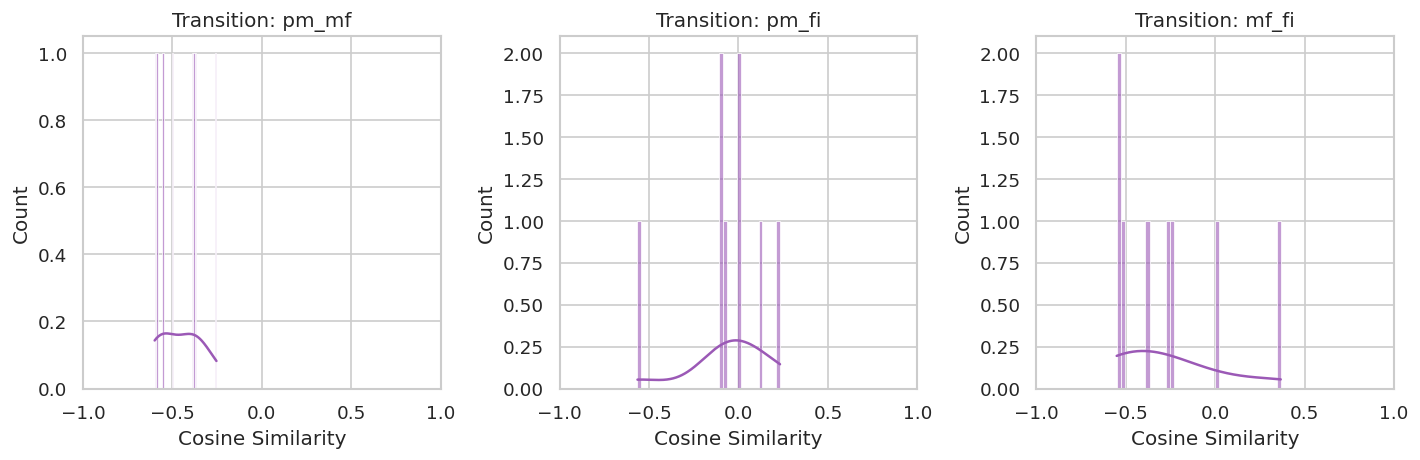

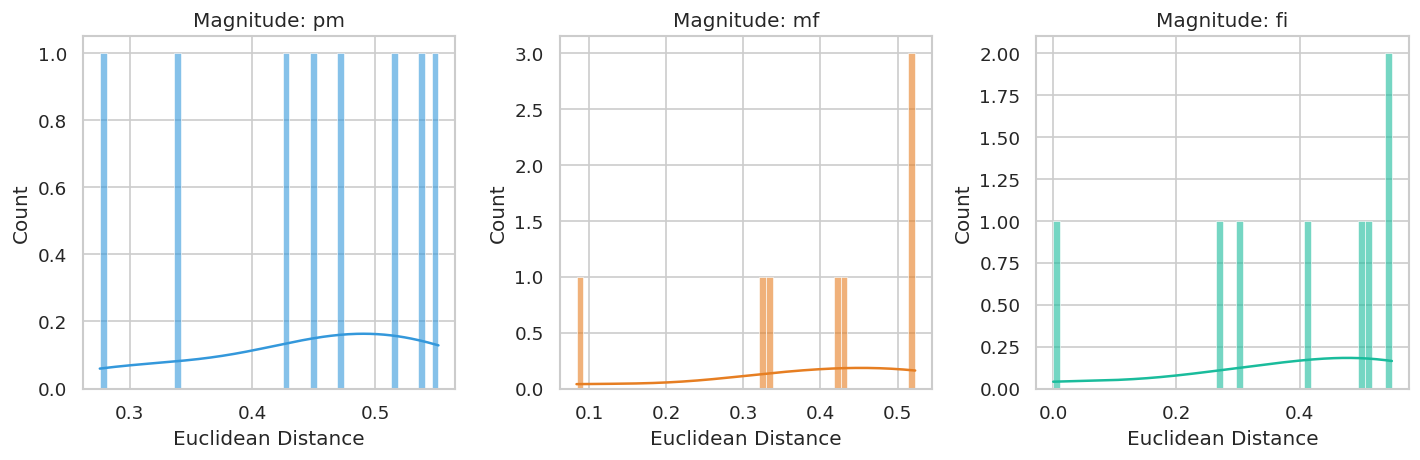

In [ ]:
art_proj = make_stage_artifact(config, BASE_PATH, "dimensionality_reduction", "dr")
# ROBUSTNESS: Load Stage 3 result from disk if it's not in memory
if 'df' not in locals() or df is None:
    try:
        art_prev = make_stage_artifact(config, BASE_PATH, "embeddings", "embeddings")
        df = load_artifact(art_prev)
        print("✅ Stage 4: Proactively loaded dependency (Stage 3) from artifact.")
    except:
        print("❌ Error: Could not find Stage 3 artifact. Please run Stage 3 first.")
try:
    if FORCE_RECOMPUTE: raise FileNotFoundError()
    df = load_artifact(art_proj)
    print("Stage 4: Loaded existing projection artifact.")
except:
    print("Stage 4: Running projection...")
    df = run_projection_stage(df, config)
    save_artifact(art_proj, df)
# Visualization
method = config["dimensionality_reduction"]["method"]
plot_projection_2d(df, method=method, draw_arrows=True, arrow_step=20)
plot_transition_signatures(df)
plot_movement_magnitudes(df)

## 5. Vector Field Computation

Stage 5: Running vector field computation...


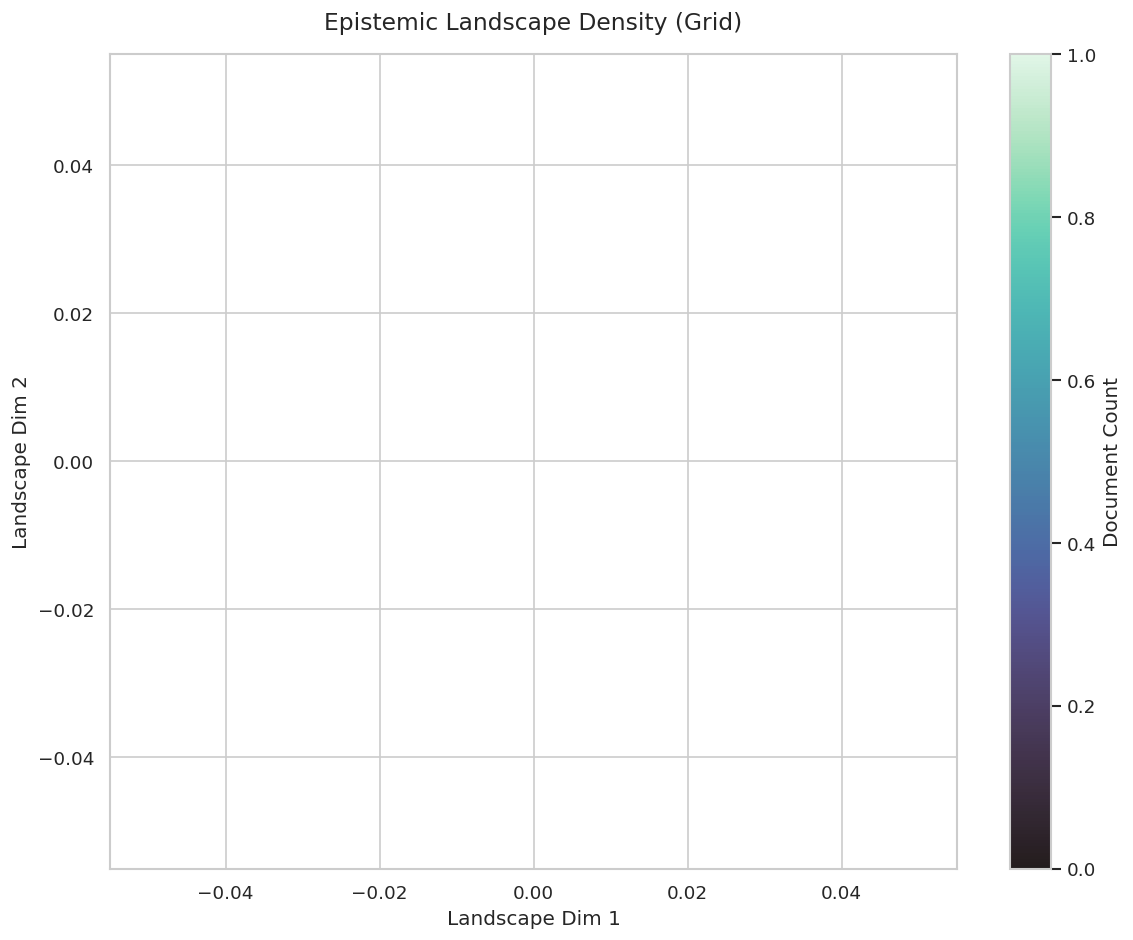

In [6]:
# Stage 5: Vector Field Computation
art_field = make_stage_artifact(config, BASE_PATH, "vector_field", "vf")

# ROBUSTNESS: Load Stage 4 result from disk if it's not in memory
if 'df' not in locals() or df is None:
    try:
        art_prev = make_stage_artifact(config, BASE_PATH, "dimensionality_reduction", "dr")
        df = load_artifact(art_prev)
        print("✅ Stage 5: Proactively loaded dependency (Stage 4) from artifact.")
    except:
        print("❌ Error: Could not find Stage 4 artifact. Please run Stage 4 first.")

try:
    if FORCE_RECOMPUTE: raise FileNotFoundError()
    field = load_artifact(art_field)
    print("Stage 5: Loaded existing vector field artifact.")
except:
    print("Stage 5: Running vector field computation...")
    field = run_vector_field_stage(df, config)
    save_artifact(art_field, field)

# Visualization
plot_vector_field(field, field_type="total", color_by_mag=True)
plot_field_magnitude(field, operator="pm")
plot_field_density(field)


## 6. Clustering (Domains & Styles)

Stage 6: Running clustering...
Running clustering: domain (source: proj_p, algorithm: hdbscan)...
Running clustering: field (source: field, algorithm: hdbscan)...
Skipping clustering field: No data found for source field
Running clustering: style (source: features, algorithm: gmm)...
Silhouette Score for style: 0.1288
Running clustering: operator (source: operators, algorithm: hdbscan)...
Skipping clustering operator: No data found for source operators


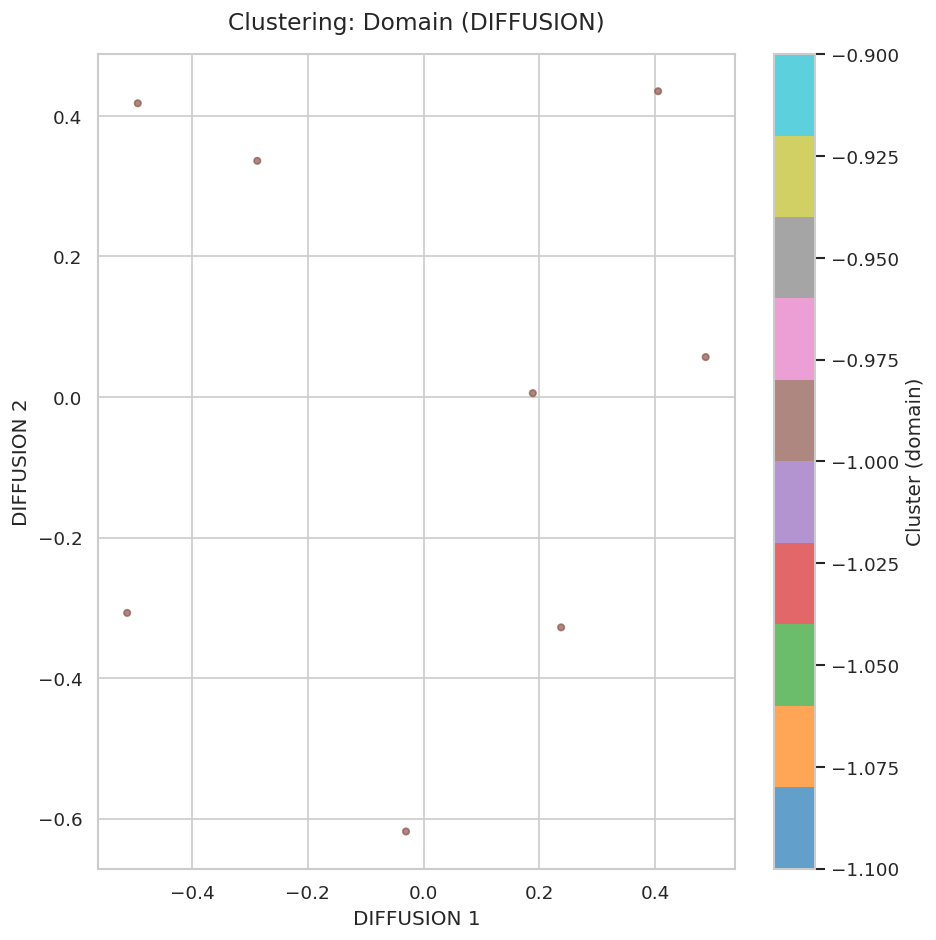

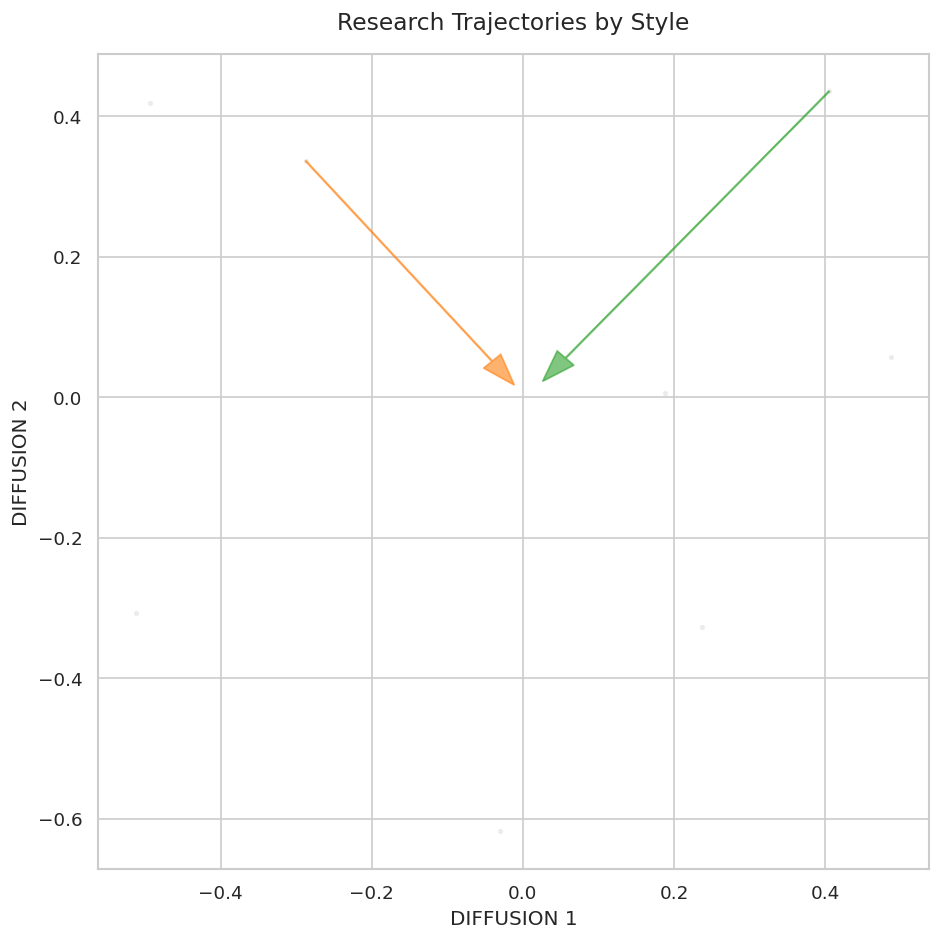

In [8]:
# Stage 6: Clustering (Domains & Styles)
art_df_clust = make_stage_artifact(config, BASE_PATH, "clustering", "clustering")
art_field_clust = make_stage_artifact(config, BASE_PATH, "clustering", "field_clustering")

# ROBUSTNESS: Load Stage 4 (df) and Stage 5 (field) results from disk if they are not in memory
if 'df' not in locals() or df is None:
    try:
        art_prev_df = make_stage_artifact(config, BASE_PATH, "dimensionality_reduction", "dr")
        df = load_artifact(art_prev_df)
        print("✅ Stage 6: Proactively loaded df (Stage 4) from artifact.")
    except:
        print("❌ Error: Could not find Stage 4 artifact.")

if 'field' not in locals() or field is None:
    try:
        art_prev_field = make_stage_artifact(config, BASE_PATH, "vector_field", "vf")
        field = load_artifact(art_prev_field)
        print("✅ Stage 6: Proactively loaded field (Stage 5) from artifact.")
    except:
        print("❌ Error: Could not find Stage 5 artifact.")


try:
    if FORCE_RECOMPUTE: raise FileNotFoundError()
    df = load_artifact(art_df_clust)
    field = load_artifact(art_field_clust)
    print("Stage 6: Loaded existing clustering artifacts.")
except:
    print("Stage 6: Running clustering...")
    df, field = run_clustering_stage(df, field, config)
    save_artifact(art_df_clust, df)
    save_artifact(art_field_clust, field)
    
# Visualization
method = config["dimensionality_reduction"]["method"]
plot_clusters_on_landscape(df, method=method, cluster_key="domain")
plot_field_clusters(field, cluster_key="field")
plot_cluster_trajectories(df, method=method, cluster_key="style")


## 7. Labeling (LLM Summarization)

In [10]:
art_labels = make_stage_artifact(config, BASE_PATH, "labeling", "labeled")
# ROBUSTNESS: Load Stage 6 clustered results if they are not in memory
if 'df' not in locals() or 'cluster_domain' not in df.columns:
    try:
        art_prev_df = make_stage_artifact(config, BASE_PATH, "clustering", "clustering")
        df = load_artifact(art_prev_df)
        print("✅ Stage 7: Proactively loaded clustered df (Stage 6) from artifact.")
    except:
        print("❌ Error: Could not find Stage 6 clustering artifact.")
if 'field' not in locals() or 'cluster_field' not in field.columns:
    try:
        art_prev_field = make_stage_artifact(config, BASE_PATH, "clustering", "field_clustering")
        field = load_artifact(art_prev_field)
        print("✅ Stage 7: Proactively loaded clustered field (Stage 6) from artifact.")
    except:
        print("❌ Error: Could not find Stage 6 field clustering artifact.")
try:
    if FORCE_RECOMPUTE: raise FileNotFoundError()
    label_results = load_artifact(art_labels)
    print("Stage 7: Loaded existing labeling artifact.")
except:
    print("Stage 7: Running labeling...")
    llm_client = get_llm_client(config.get("labeling", {}))
    label_results = run_labeling_stage(df, field, config, llm_client)
    save_artifact(art_labels, label_results)
    
# Visualization
print_cluster_summaries(label_results, cluster_key="domain")

✅ Stage 7: Proactively loaded clustered field (Stage 6) from artifact.
Stage 7: Running labeling...
Labeling axes for projection: diffusion...
Labeling clusters for: domain...
Labeling clusters for: style...
No labels found for cluster key: domain


## 8. Landscape & Final Visualizations

In [ ]:
art_landscape = make_stage_artifact(config, BASE_PATH, "output", "landscape_results")
# ROBUSTNESS: Hydrate memory from all previous stages if needed
if 'df' not in locals() or 'cluster_domain' not in df.columns:
    df = load_artifact(make_stage_artifact(config, BASE_PATH, "clustering", "clustering"))
    print("✅ Stage 8: Loaded clustered df (Stage 6)")
if 'field' not in locals() or 'cluster_field' not in field.columns:
    field = load_artifact(make_stage_artifact(config, BASE_PATH, "clustering", "field_clustering"))
    print("✅ Stage 8: Loaded clustered field (Stage 6)")
if 'label_results' not in locals():
    label_results = load_artifact(make_stage_artifact(config, BASE_PATH, "labeling", "labeled"))
    print("✅ Stage 8: Loaded labels (Stage 7)")
try:
    if FORCE_RECOMPUTE: raise FileNotFoundError()
    landscape_results = load_artifact(art_landscape)
    print("Stage 8: Loaded existing landscape artifact.")
except:
    print("Stage 8: Running landscape preparation...")
    landscape_results = run_landscape_stage(df, field, config)
    save_artifact(art_landscape, landscape_results)

# Parameters for plotting
topic_name = config["data"]["provider"]["topic_name"]
method = config["dimensionality_reduction"]["method"]

### 1. Final Epistemic Map (Static 2D)

In [ ]:
plot_epistemic_map(df, label_results, method=method, topic_name=topic_name)

### 2. Interactive 2D Contour Map (Plotly)

In [ ]:
plot_landscape_contour(df, landscape_results, field=field, topic_name=topic_name)

### 3. Interactive 3D Surface (Plotly)

In [ ]:
plot_landscape_3d(df, landscape_results, topic_name=topic_name)